# Блок 1: Импорт необходимых библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


# Блок 2: Загрузка датасетов

In [2]:
# Блок 2: Загрузка датасетов
print("=== ЗАГРУЗКА ДАТАСЕТОВ ===")

try:
    # Загрузка датасета Gun Violence
    gun_data = pd.read_csv('gun-violence-data.csv')
    
    # Загрузка датасета Anime
    anime_data = pd.read_csv('anime.csv')
    
    print("Датасеты успешно загружены")
    print(f"Gun Violence Data: {gun_data.shape}")
    print(f"Anime Data: {anime_data.shape}")
    
except FileNotFoundError as e:
    print(f"Ошибка загрузки файлов: {e}")
    print("Убедитесь, что файлы находятся в той же директории")

=== ЗАГРУЗКА ДАТАСЕТОВ ===
Датасеты успешно загружены
Gun Violence Data: (239677, 29)
Anime Data: (12294, 7)


# Блок 3: Предобработка данных для регрессии (Gun Violence)

Размер датасета для регрессии: (10000, 6)
Распределение целевой переменной:
count    10000.000000
mean         0.695900
std          0.832642
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         25.000000
Name: total_victims, dtype: float64


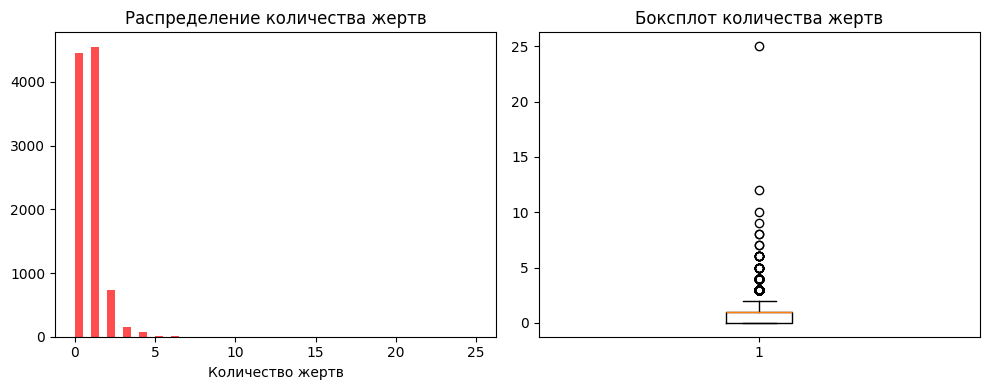

In [3]:
# Создание целевой переменной
gun_data['total_victims'] = gun_data['n_killed'] + gun_data['n_injured']

# Удаление неиспользуемых столбцов
used_columns_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county', 'total_victims']
gun_data_reduced = gun_data[used_columns_reg].copy()

# Удаление строк с пропущенными значениями
gun_data_clean = gun_data_reduced.dropna()

# Ограничим данные для ускорения (опционально)
if gun_data_clean.shape[0] > 10000:
    gun_data_clean = gun_data_clean.sample(n=10000, random_state=42, replace=False)

print(f"Размер датасета для регрессии: {gun_data_clean.shape}")
print(f"Распределение целевой переменной:")
print(gun_data_clean['total_victims'].describe())

# Визуализация распределения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(gun_data_clean['total_victims'], bins=50, alpha=0.7, color='red')
plt.title('Распределение количества жертв')
plt.xlabel('Количество жертв')

plt.subplot(1, 2, 2)
plt.boxplot(gun_data_clean['total_victims'])
plt.title('Боксплот количества жертв')
plt.tight_layout()
plt.show()

# Блок 4: Предобработка данных для классификации (Anime)

Размер датасета для классификации: (5000, 5)
Распределение типов аниме:
type
TV         1706
OVA        1492
Movie      1022
Special     780
Name: count, dtype: int64


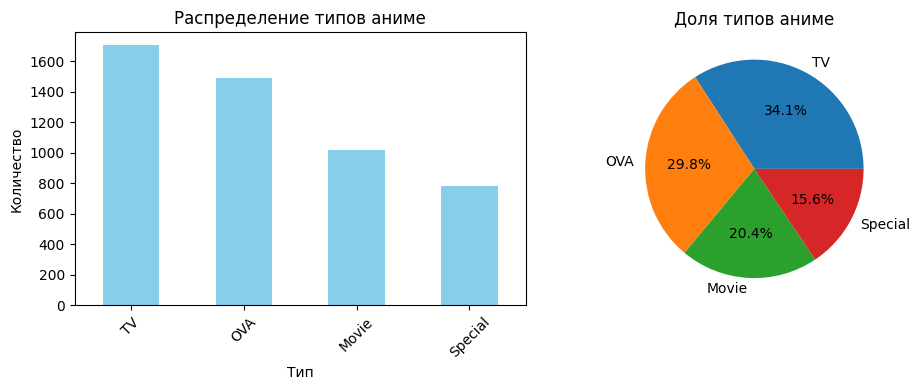

In [4]:
# Удаление неиспользуемых столбцов
used_columns_clf = ['episodes', 'rating', 'members', 'genre', 'type']
anime_data_reduced = anime_data[used_columns_clf].copy()

# Удаление строк с пропущенными значениями
anime_data_clean = anime_data_reduced.dropna()

# Оставляем основные типы
main_types = ['TV', 'Movie', 'OVA', 'Special']
anime_data_clean = anime_data_clean[anime_data_clean['type'].isin(main_types)]

# Ограничим данные для ускорения (опционально)
if anime_data_clean.shape[0] > 5000:
    anime_data_clean = anime_data_clean.sample(n=5000, random_state=42, replace=False)

print(f"Размер датасета для классификации: {anime_data_clean.shape}")
print(f"Распределение типов аниме:")
type_counts = anime_data_clean['type'].value_counts()
print(type_counts)

# Визуализация распределения классов
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
type_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение типов аниме')
plt.xlabel('Тип')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
plt.title('Доля типов аниме')
plt.tight_layout()
plt.show()

# Блок 5: Подготовка признаков для регрессии

In [5]:
# Разделение на признаки и целевую переменную
features_reg = ['latitude', 'longitude', 'n_guns_involved', 'state', 'city_or_county']
target_reg = 'total_victims'

X_reg = gun_data_clean[features_reg].copy()
y_reg = gun_data_clean[target_reg]

# One-Hot Encoding для категориальных признаков
X_reg_encoded = pd.get_dummies(X_reg, columns=['state', 'city_or_county'], drop_first=True)

# Ограничение количества признаков (берем только топ-20 по частоте)
if X_reg_encoded.shape[1] > 50:
    # Выбираем только числовые признаки + топ категориальных
    numeric_cols = ['latitude', 'longitude', 'n_guns_involved']
    cat_cols = [col for col in X_reg_encoded.columns if col not in numeric_cols]
    # Берем только первые 20 категориальных признаков
    selected_cols = numeric_cols + cat_cols[:20]
    X_reg_encoded = X_reg_encoded[selected_cols]

# Заполнение пропущенных значений
imputer_reg = SimpleImputer(strategy='median')
X_reg_imputed = pd.DataFrame(imputer_reg.fit_transform(X_reg_encoded), columns=X_reg_encoded.columns)

# Масштабирование признаков
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg_imputed)

# Разделение на train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

print(f"Размеры выборок для регрессии:")
print(f"Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")
print(f"Количество признаков: {X_train_reg.shape[1]}")

Размеры выборок для регрессии:
Train: (8000, 23), Test: (2000, 23)
Количество признаков: 23


# Блок 6: Подготовка признаков для классификации

In [6]:
# Разделение на признаки и целевую переменную
features_clf = ['episodes', 'rating', 'members', 'genre']
target_clf = 'type'

X_clf = anime_data_clean[features_clf].copy()
y_clf = anime_data_clean[target_clf]

# Обработка признаков
X_clf['episodes'] = pd.to_numeric(X_clf['episodes'], errors='coerce')
X_clf['main_genre'] = X_clf['genre'].str.split(',').str[0].fillna('Unknown')

# Кодирование категориальных признаков
label_encoder = LabelEncoder()
X_clf['main_genre_encoded'] = label_encoder.fit_transform(X_clf['main_genre'])

# Выбор финальных признаков
X_clf_processed = X_clf[['episodes', 'rating', 'members', 'main_genre_encoded']]

# Заполнение пропущенных значений
imputer_clf = SimpleImputer(strategy='median')
X_clf_imputed = pd.DataFrame(imputer_clf.fit_transform(X_clf_processed), 
                            columns=X_clf_processed.columns)

# Масштабирование признаков
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf_imputed)

# Кодирование целевой переменной
label_encoder_target = LabelEncoder()
y_clf_encoded = label_encoder_target.fit_transform(y_clf)

# Разделение на train/test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded
)

print(f"Размеры выборок для классификации:")
print(f"Train: {X_train_clf.shape}, Test: {X_test_clf.shape}")
print(f"Количество классов: {len(label_encoder_target.classes_)}")
print(f"Классы: {label_encoder_target.classes_}")

Размеры выборок для классификации:
Train: (4000, 4), Test: (1000, 4)
Количество классов: 4
Классы: ['Movie' 'OVA' 'Special' 'TV']


# Блок 7: Бейзлайн модели из sklearn

In [7]:
# Линейная регрессия
lin_reg_baseline = LinearRegression()
lin_reg_baseline.fit(X_train_reg, y_train_reg)
y_pred_reg_baseline = lin_reg_baseline.predict(X_test_reg)

# Логистическая регрессия (для многоклассовой классификации)
log_reg_baseline = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
log_reg_baseline.fit(X_train_clf, y_train_clf)
y_pred_clf_baseline = log_reg_baseline.predict(X_test_clf)

print("Бейзлайн модели обучены")

Бейзлайн модели обучены


# Блок 8: Оценка качества бейзлайн моделей


--- ЛИНЕЙНАЯ РЕГРЕССИЯ (Gun Violence) ---
MAE: 0.5842
RMSE: 0.7476
R² Score: 0.0287

--- ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Anime) ---
Accuracy: 0.6490
Precision: 0.5773
Recall: 0.6490
F1-Score: 0.5931

Classification Report:
              precision    recall  f1-score   support

       Movie       0.54      0.34      0.42       204
         OVA       0.48      0.85      0.61       299
     Special       0.00      0.00      0.00       156
          TV       0.95      0.96      0.95       341

    accuracy                           0.65      1000
   macro avg       0.49      0.54      0.50      1000
weighted avg       0.58      0.65      0.59      1000



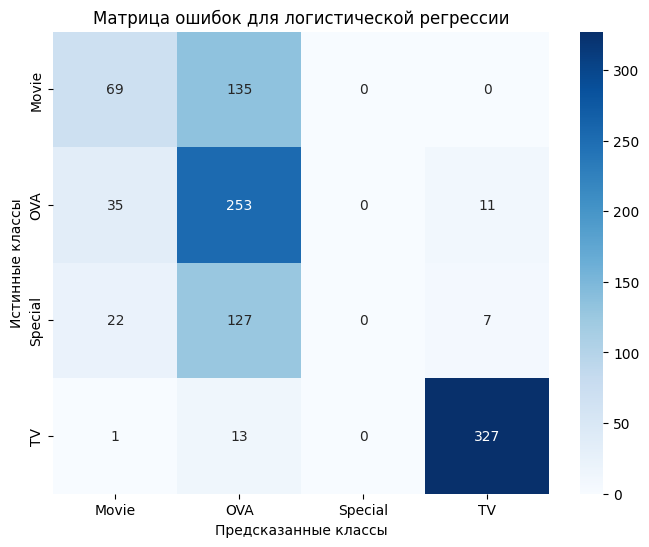

In [8]:
print("\n--- ЛИНЕЙНАЯ РЕГРЕССИЯ (Gun Violence) ---")
mae_baseline = mean_absolute_error(y_test_reg, y_pred_reg_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_baseline))
r2_baseline = r2_score(y_test_reg, y_pred_reg_baseline)

print(f"MAE: {mae_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"R² Score: {r2_baseline:.4f}")

print("\n--- ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (Anime) ---")
accuracy_baseline = accuracy_score(y_test_clf, y_pred_clf_baseline)
precision_baseline = precision_score(y_test_clf, y_pred_clf_baseline, average='weighted')
recall_baseline = recall_score(y_test_clf, y_pred_clf_baseline, average='weighted')
f1_baseline = f1_score(y_test_clf, y_pred_clf_baseline, average='weighted')

print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall: {recall_baseline:.4f}")
print(f"F1-Score: {f1_baseline:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf_baseline, 
                          target_names=label_encoder_target.classes_))

# Матрица ошибок
cm = confusion_matrix(y_test_clf, y_pred_clf_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder_target.classes_, 
            yticklabels=label_encoder_target.classes_)
plt.title('Матрица ошибок для логистической регрессии')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

# Формулировка гипотез для улучшения

## ГИПОТЕЗЫ ДЛЯ РЕГРЕССИИ:
1. Добавление полиномиальных признаков (степень 2)
2. Использование регуляризации (Ridge, Lasso, ElasticNet)
3. Отбор наиболее важных признаков
4. Настройка гиперпараметров моделей

## ГИПОТЕЗЫ ДЛЯ КЛАССИФИКАЦИИ:
1. Балансировка классов (class_weight)
2. Использование разных солверов для логистической регрессии
3. Отбор признаков
4. Настройка параметра регуляризации C
5. Использование полиномиальных признаков


# Блок 9: Проверка гипотез - регрессия

In [9]:
# Создание пайплайнов для разных подходов
pipelines_reg = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

# Обучение и оценка всех моделей
results_reg = {}
for name, model in pipelines_reg.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)
    
    results_reg[name] = {
        'MAE': mean_absolute_error(y_test_reg, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred)),
        'R2': r2_score(y_test_reg, y_pred)
    }
    print(f"{name}: MAE={results_reg[name]['MAE']:.4f}, R2={results_reg[name]['R2']:.4f}")

# Визуализация результатов
results_df_reg = pd.DataFrame(results_reg).T
print("\nСравнение моделей регрессии:")
print(results_df_reg)

Linear: MAE=0.5842, R2=0.0287
Ridge: MAE=0.5843, R2=0.0287
Lasso: MAE=0.5909, R2=0.0271
ElasticNet: MAE=0.5880, R2=0.0287

Сравнение моделей регрессии:
                 MAE      RMSE        R2
Linear      0.584247  0.747637  0.028684
Ridge       0.584252  0.747636  0.028687
Lasso       0.590928  0.748256  0.027075
ElasticNet  0.587961  0.747628  0.028707


# Блок 10: Проверка гипотез - классификация

In [10]:
# Создание пайплайнов для разных подходов
pipelines_clf = {
    'Logistic_Default': LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
    'Logistic_Balanced': LogisticRegression(multi_class='multinomial', class_weight='balanced', max_iter=1000, random_state=42),
    'Logistic_liblinear': LogisticRegression(solver='liblinear', max_iter=1000, random_state=42),
    'Logistic_saga': LogisticRegression(solver='saga', max_iter=1000, random_state=42)
}

# Обучение и оценка всех моделей
results_clf = {}
for name, model in pipelines_clf.items():
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    
    results_clf[name] = {
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred, average='weighted'),
        'Recall': recall_score(y_test_clf, y_pred, average='weighted'),
        'F1': f1_score(y_test_clf, y_pred, average='weighted')
    }
    print(f"{name}: Accuracy={results_clf[name]['Accuracy']:.4f}, F1={results_clf[name]['F1']:.4f}")

# Визуализация результатов
results_df_clf = pd.DataFrame(results_clf).T
print("\nСравнение моделей классификации:")
print(results_df_clf)

Logistic_Default: Accuracy=0.6490, F1=0.5931
Logistic_Balanced: Accuracy=0.6230, F1=0.6177
Logistic_liblinear: Accuracy=0.6400, F1=0.5758
Logistic_saga: Accuracy=0.6480, F1=0.5915

Сравнение моделей классификации:
                    Accuracy  Precision  Recall        F1
Logistic_Default       0.649   0.577314   0.649  0.593088
Logistic_Balanced      0.623   0.645164   0.623  0.617738
Logistic_liblinear     0.640   0.571105   0.640  0.575834
Logistic_saga          0.648   0.577729   0.648  0.591509


# Блок 11: Подбор гиперпараметров на кросс-валидации

In [11]:
# Для регрессии (Ridge)
print("Подбор гиперпараметров для Ridge регрессии...")
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_grid = GridSearchCV(Ridge(), param_grid_ridge, cv=5, 
                         scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_reg, y_train_reg)

print(f"Лучшие параметры для Ridge: {ridge_grid.best_params_}")
print(f"Лучший RMSE: {np.sqrt(-ridge_grid.best_score_):.4f}")

# Для классификации (Logistic Regression)
print("\nПодбор гиперпараметров для логистической регрессии...")
param_grid_log = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'liblinear', 'saga']
}

log_grid = GridSearchCV(LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42), 
                       param_grid_log, cv=5, scoring='accuracy', n_jobs=-1)
log_grid.fit(X_train_clf, y_train_clf)

print(f"Лучшие параметры для Logistic Regression: {log_grid.best_params_}")
print(f"Лучшая точность: {log_grid.best_score_:.4f}")

Подбор гиперпараметров для Ridge регрессии...
Лучшие параметры для Ridge: {'alpha': 100.0}
Лучший RMSE: 0.8434

Подбор гиперпараметров для логистической регрессии...
Лучшие параметры для Logistic Regression: {'C': 100.0, 'solver': 'lbfgs'}
Лучшая точность: 0.6855


# Блок 12: Улучшенные модели с подобранными гиперпараметрами

In [12]:
# Улучшенная модель регрессии
ridge_improved = ridge_grid.best_estimator_
y_pred_reg_improved = ridge_improved.predict(X_test_reg)

# Улучшенная модель классификации
log_improved = log_grid.best_estimator_
y_pred_clf_improved = log_improved.predict(X_test_clf)

print("Улучшенные модели обучены")

Улучшенные модели обучены


# Блок 13: Оценка улучшенных моделей

In [13]:
print("\n--- РЕГРЕССИЯ (Ridge) - УЛУЧШЕННАЯ ---")
mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_improved))
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print(f"MAE: {mae_improved:.4f} (было: {mae_baseline:.4f})")
print(f"RMSE: {rmse_improved:.4f} (было: {rmse_baseline:.4f})")
print(f"R² Score: {r2_improved:.4f} (было: {r2_baseline:.4f})")

print("\n--- КЛАССИФИКАЦИЯ (Logistic) - УЛУЧШЕННАЯ ---")
accuracy_improved = accuracy_score(y_test_clf, y_pred_clf_improved)
precision_improved = precision_score(y_test_clf, y_pred_clf_improved, average='weighted')
recall_improved = recall_score(y_test_clf, y_pred_clf_improved, average='weighted')
f1_improved = f1_score(y_test_clf, y_pred_clf_improved, average='weighted')

print(f"Accuracy: {accuracy_improved:.4f} (было: {accuracy_baseline:.4f})")
print(f"Precision: {precision_improved:.4f} (было: {precision_baseline:.4f})")
print(f"Recall: {recall_improved:.4f} (было: {recall_baseline:.4f})")
print(f"F1-Score: {f1_improved:.4f} (было: {f1_baseline:.4f})")

print("\nClassification Report (улучшенная):")
print(classification_report(y_test_clf, y_pred_clf_improved, 
                          target_names=label_encoder_target.classes_))


--- РЕГРЕССИЯ (Ridge) - УЛУЧШЕННАЯ ---
MAE: 0.5847 (было: 0.5842)
RMSE: 0.7475 (было: 0.7476)
R² Score: 0.0290 (было: 0.0287)

--- КЛАССИФИКАЦИЯ (Logistic) - УЛУЧШЕННАЯ ---
Accuracy: 0.6640 (было: 0.6490)
Precision: 0.5822 (было: 0.5773)
Recall: 0.6640 (было: 0.6490)
F1-Score: 0.6181 (было: 0.5931)

Classification Report (улучшенная):
              precision    recall  f1-score   support

       Movie       0.45      0.61      0.52       204
         OVA       0.56      0.71      0.63       299
     Special       0.00      0.00      0.00       156
          TV       0.95      0.96      0.95       341

    accuracy                           0.66      1000
   macro avg       0.49      0.57      0.52      1000
weighted avg       0.58      0.66      0.62      1000



# Блок 14: Сравнение результатов улучшенных моделей

In [14]:
print("\nУЛУЧШЕНИЯ РЕГРЕССИИ:")
improvement_mae = ((mae_baseline - mae_improved) / mae_baseline) * 100
improvement_rmse = ((rmse_baseline - rmse_improved) / rmse_baseline) * 100
improvement_r2 = ((r2_improved - r2_baseline) / abs(r2_baseline)) * 100

print(f"Улучшение MAE: {improvement_mae:+.2f}%")
print(f"Улучшение RMSE: {improvement_rmse:+.2f}%") 
print(f"Улучшение R²: {improvement_r2:+.2f}%")

print("\nУЛУЧШЕНИЯ КЛАССИФИКАЦИИ:")
improvement_accuracy = ((accuracy_improved - accuracy_baseline) / accuracy_baseline) * 100
improvement_f1 = ((f1_improved - f1_baseline) / f1_baseline) * 100

print(f"Улучшение Accuracy: {improvement_accuracy:+.2f}%")
print(f"Улучшение F1-Score: {improvement_f1:+.2f}%")


УЛУЧШЕНИЯ РЕГРЕССИИ:
Улучшение MAE: -0.08%
Улучшение RMSE: +0.02%
Улучшение R²: +1.04%

УЛУЧШЕНИЯ КЛАССИФИКАЦИИ:
Улучшение Accuracy: +2.31%
Улучшение F1-Score: +4.21%


# Блок 15: Реализация собственного алгоритма линейной регрессии

Обучаем собственную линейную регрессию...
Итерация 0: Cost = 0.599759
Итерация 100: Cost = 0.386725
Итерация 200: Cost = 0.357693
Итерация 300: Cost = 0.353463
Итерация 400: Cost = 0.352690
Собственная линейная регрессия обучена


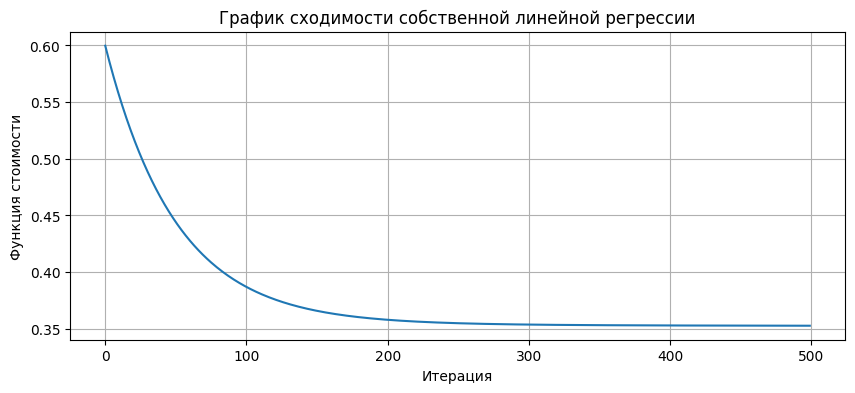

In [15]:
class MyLinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, regularization=None, alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.regularization = regularization  # None, 'l1', 'l2'
        self.alpha = alpha
        
    def _add_intercept(self, X):
        intercept = np.ones((X.shape[0], 1))
        return np.concatenate((intercept, X), axis=1)
    
    def _compute_cost(self, X, y):
        predictions = X.dot(self.theta)
        errors = predictions - y
        cost = (1 / (2 * self.m)) * np.sum(errors ** 2)
        
        # Регуляризация
        if self.regularization == 'l2':
            cost += (self.alpha / (2 * self.m)) * np.sum(self.theta[1:] ** 2)
        elif self.regularization == 'l1':
            cost += (self.alpha / self.m) * np.sum(np.abs(self.theta[1:]))
            
        return cost
    
    def fit(self, X, y):
        # Добавляем intercept
        X = self._add_intercept(X)
        self.m = X.shape[0]  # Количество примеров
        self.n = X.shape[1]  # Количество признаков + 1
        
        # Инициализация параметров
        self.theta = np.zeros(self.n)
        self.cost_history = []
        
        # Градиентный спуск
        for iteration in range(self.n_iterations):
            predictions = X.dot(self.theta)
            errors = predictions - y
            
            # Вычисление градиента
            gradient = (1 / self.m) * X.T.dot(errors)
            
            # Регуляризация градиента
            if self.regularization == 'l2':
                gradient[1:] += (self.alpha / self.m) * self.theta[1:]
            elif self.regularization == 'l1':
                gradient[1:] += (self.alpha / self.m) * np.sign(self.theta[1:])
            
            # Обновление параметров
            self.theta -= self.learning_rate * gradient
            
            # Сохранение стоимости
            cost = self._compute_cost(X, y)
            self.cost_history.append(cost)
            
            if iteration % 100 == 0:
                print(f"Итерация {iteration}: Cost = {cost:.6f}")
        
        return self
    
    def predict(self, X):
        X = self._add_intercept(X)
        return X.dot(self.theta)

# Тестирование собственной линейной регрессии
print("Обучаем собственную линейную регрессию...")
my_lin_reg = MyLinearRegression(learning_rate=0.01, n_iterations=500)
my_lin_reg.fit(X_train_reg, y_train_reg.values)
y_pred_my_reg = my_lin_reg.predict(X_test_reg)

print("Собственная линейная регрессия обучена")

# Визуализация сходимости
plt.figure(figsize=(10, 4))
plt.plot(my_lin_reg.cost_history)
plt.title('График сходимости собственной линейной регрессии')
plt.xlabel('Итерация')
plt.ylabel('Функция стоимости')
plt.grid(True)
plt.show()

# Блок 16: Реализация собственного алгоритма логистической регрессии (исправленная версия)

Обучаем собственную логистическую регрессию...
Размер обучающей выборки: (1000, 4)
Размер тестовой выборки: (200, 4)
Обнаружено 4 классов: [0 1 2 3]
Обучаем для класса 0 (1/4)...
  Итерация 200: Cost = 0.449651
  Класс 0 обучен. Final cost = 0.446204
Обучаем для класса 1 (2/4)...
  Итерация 200: Cost = 0.534461
  Класс 1 обучен. Final cost = 0.529242
Обучаем для класса 2 (3/4)...
  Итерация 200: Cost = 0.426654
  Класс 2 обучен. Final cost = 0.423768
Обучаем для класса 3 (4/4)...
  Итерация 200: Cost = 0.388553
  Класс 3 обучен. Final cost = 0.370280
Обучение завершено!
Собственная логистическая регрессия обучена


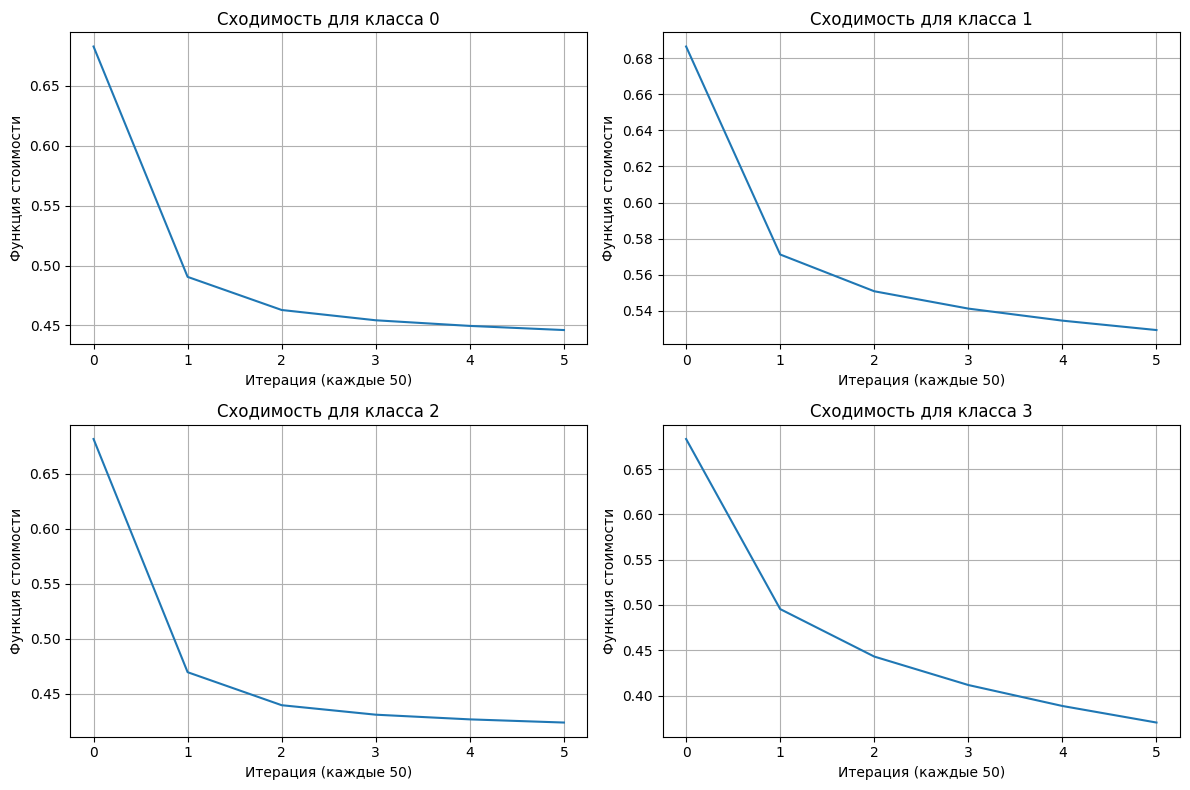

In [16]:
class MyLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, regularization=None, alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.regularization = regularization
        self.alpha = alpha
        
    def _sigmoid(self, z):
        # Защита от переполнения
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _add_intercept(self, X):
        intercept = np.ones((X.shape[0], 1))
        return np.concatenate((intercept, X), axis=1)
    
    def _compute_cost(self, X, y, theta):
        """Вычисление функции стоимости для заданного theta"""
        m = len(y)
        h = self._sigmoid(X.dot(theta))
        
        # Избегаем log(0) путем добавления небольшого значения
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        
        cost = (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))
        
        # Регуляризация
        if self.regularization == 'l2':
            cost += (self.alpha / (2*m)) * np.sum(theta[1:] ** 2)
        elif self.regularization == 'l1':
            cost += (self.alpha / m) * np.sum(np.abs(theta[1:]))
            
        return cost
    
    def fit(self, X, y):
        """Обучение модели методом one-vs-rest"""
        self.classes_ = np.unique(y)
        self.theta_list = []
        self.cost_history_list = []
        
        print(f"Обнаружено {len(self.classes_)} классов: {self.classes_}")
        
        for i, class_label in enumerate(self.classes_):
            print(f"Обучаем для класса {class_label} ({i+1}/{len(self.classes_)})...")
            
            # Бинарные метки для текущего класса
            y_binary = np.where(y == class_label, 1, 0)
            
            # Добавляем intercept
            X_with_intercept = self._add_intercept(X)
            m, n = X_with_intercept.shape
            
            # Инициализация параметров
            theta = np.zeros(n)
            cost_history = []
            
            # Градиентный спуск
            for iteration in range(self.n_iterations):
                # Вычисляем предсказания
                h = self._sigmoid(X_with_intercept.dot(theta))
                
                # Вычисляем градиент
                gradient = (1/m) * X_with_intercept.T.dot(h - y_binary)
                
                # Регуляризация градиента
                if self.regularization == 'l2':
                    gradient[1:] += (self.alpha / m) * theta[1:]
                elif self.regularization == 'l1':
                    gradient[1:] += (self.alpha / m) * np.sign(theta[1:])
                
                # Обновление параметров
                theta -= self.learning_rate * gradient
                
                # Сохранение стоимости каждые 50 итераций
                if iteration % 50 == 0:
                    cost = self._compute_cost(X_with_intercept, y_binary, theta)
                    cost_history.append(cost)
                    
                    if iteration % 200 == 0 and iteration > 0:
                        print(f"  Итерация {iteration}: Cost = {cost:.6f}")
            
            # Сохраняем theta для текущего класса
            self.theta_list.append(theta)
            self.cost_history_list.append(cost_history)
            
            print(f"  Класс {class_label} обучен. Final cost = {cost_history[-1]:.6f}")
        
        print("Обучение завершено!")
        return self
    
    def predict_proba(self, X):
        """Предсказание вероятностей"""
        X_with_intercept = self._add_intercept(X)
        probabilities = []
        
        for theta in self.theta_list:
            prob = self._sigmoid(X_with_intercept.dot(theta))
            probabilities.append(prob)
        
        # Нормализуем вероятности, чтобы они суммировались в 1
        prob_matrix = np.column_stack(probabilities)
        # Для многоклассовой классификации используем softmax
        exp_probs = np.exp(prob_matrix)
        return exp_probs / np.sum(exp_probs, axis=1, keepdims=True)
    
    def predict(self, X):
        """Предсказание классов"""
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)

# Тестирование собственной логистической регрессии (ограничим данные для скорости)
print("Обучаем собственную логистическую регрессию...")
max_samples = min(1000, X_train_clf.shape[0])
X_train_clf_small = X_train_clf[:max_samples]
y_train_clf_small = y_train_clf[:max_samples]
X_test_clf_small = X_test_clf[:200]
y_test_clf_small = y_test_clf[:200]

print(f"Размер обучающей выборки: {X_train_clf_small.shape}")
print(f"Размер тестовой выборки: {X_test_clf_small.shape}")

my_log_reg = MyLogisticRegression(learning_rate=0.1, n_iterations=300)
my_log_reg.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf = my_log_reg.predict(X_test_clf_small)

print("Собственная логистическая регрессия обучена")

# Визуализация сходимости для всех классов
plt.figure(figsize=(12, 8))
for i, (cost_history, class_label) in enumerate(zip(my_log_reg.cost_history_list, my_log_reg.classes_)):
    plt.subplot(2, 2, i+1)
    plt.plot(cost_history)
    plt.title(f'Сходимость для класса {class_label}')
    plt.xlabel('Итерация (каждые 50)')
    plt.ylabel('Функция стоимости')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Блок 17: Оценка собственных реализаций

In [17]:
print("\n--- СОБСТВЕННАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ ---")
mae_my_reg = mean_absolute_error(y_test_reg, y_pred_my_reg)
rmse_my_reg = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg))
r2_my_reg = r2_score(y_test_reg, y_pred_my_reg)

print(f"MAE: {mae_my_reg:.4f} (sklearn: {mae_baseline:.4f})")
print(f"RMSE: {rmse_my_reg:.4f} (sklearn: {rmse_baseline:.4f})")
print(f"R² Score: {r2_my_reg:.4f} (sklearn: {r2_baseline:.4f})")

print("\n--- СОБСТВЕННАЯ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ ---")
accuracy_my_clf = accuracy_score(y_test_clf_small, y_pred_my_clf)
print(f"Accuracy: {accuracy_my_clf:.4f} (sklearn на полных данных: {accuracy_baseline:.4f})")

# Переобучим sklearn на тех же данных для честного сравнения
log_reg_small = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
log_reg_small.fit(X_train_clf_small, y_train_clf_small)
y_pred_sklearn_small = log_reg_small.predict(X_test_clf_small)
accuracy_sklearn_small = accuracy_score(y_test_clf_small, y_pred_sklearn_small)
print(f"Sklearn на тех же данных: {accuracy_sklearn_small:.4f}")


--- СОБСТВЕННАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ ---
MAE: 0.5864 (sklearn: 0.5842)
RMSE: 0.7470 (sklearn: 0.7476)
R² Score: 0.0304 (sklearn: 0.0287)

--- СОБСТВЕННАЯ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ ---
Accuracy: 0.6250 (sklearn на полных данных: 0.6490)
Sklearn на тех же данных: 0.6550


# Блок 18: Применение улучшений к собственным реализациям

In [18]:
# Используем лучшие параметры из GridSearchCV
best_params_ridge = ridge_grid.best_params_
best_params_log = log_grid.best_params_

print(f"Лучшие параметры для Ridge: {best_params_ridge}")
print(f"Лучшие параметры для Logistic: {best_params_log}")

# Улучшенная собственная линейная регрессия (с регуляризацией L2)
print("\nОбучаем улучшенную собственную линейную регрессию (с регуляризацией)...")
my_lin_reg_improved = MyLinearRegression(
    learning_rate=0.01, 
    n_iterations=500,
    regularization='l2',
    alpha=best_params_ridge['alpha']
)
my_lin_reg_improved.fit(X_train_reg, y_train_reg.values)
y_pred_my_reg_improved = my_lin_reg_improved.predict(X_test_reg)

# Улучшенная собственная логистическая регрессия (с регуляризацией)
print("\nОбучаем улучшенную собственную логистическую регрессию...")
my_log_reg_improved = MyLogisticRegression(
    learning_rate=0.1,
    n_iterations=300,
    regularization='l2',
    alpha=1.0 / best_params_log['C']  # Преобразуем C в alpha
)
my_log_reg_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_my_clf_improved = my_log_reg_improved.predict(X_test_clf_small)

print("Улучшенные собственные реализации обучены")

Лучшие параметры для Ridge: {'alpha': 100.0}
Лучшие параметры для Logistic: {'C': 100.0, 'solver': 'lbfgs'}

Обучаем улучшенную собственную линейную регрессию (с регуляризацией)...
Итерация 0: Cost = 0.599759
Итерация 100: Cost = 0.386784
Итерация 200: Cost = 0.357798
Итерация 300: Cost = 0.353598
Итерация 400: Cost = 0.352848

Обучаем улучшенную собственную логистическую регрессию...
Обнаружено 4 классов: [0 1 2 3]
Обучаем для класса 0 (1/4)...
  Итерация 200: Cost = 0.449655
  Класс 0 обучен. Final cost = 0.446210
Обучаем для класса 1 (2/4)...
  Итерация 200: Cost = 0.534469
  Класс 1 обучен. Final cost = 0.529252
Обучаем для класса 2 (3/4)...
  Итерация 200: Cost = 0.426657
  Класс 2 обучен. Final cost = 0.423773
Обучаем для класса 3 (4/4)...
  Итерация 200: Cost = 0.388585
  Класс 3 обучен. Final cost = 0.370321
Обучение завершено!
Улучшенные собственные реализации обучены


# Блок 19: Финальное сравнение всех моделей

In [19]:
# Вычисление метрик для улучшенных собственных реализаций
mae_my_reg_improved = mean_absolute_error(y_test_reg, y_pred_my_reg_improved)
rmse_my_reg_improved = np.sqrt(mean_squared_error(y_test_reg, y_pred_my_reg_improved))
r2_my_reg_improved = r2_score(y_test_reg, y_pred_my_reg_improved)
accuracy_my_clf_improved = accuracy_score(y_test_clf_small, y_pred_my_clf_improved)

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)")
print("="*70)
results_reg = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My LR Baseline', 'My LR Improved'],
    'MAE': [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved],
    'RMSE': [rmse_baseline, rmse_improved, rmse_my_reg, rmse_my_reg_improved],
    'R²': [r2_baseline, r2_improved, r2_my_reg, r2_my_reg_improved]
})
print(results_reg.round(4))

print("\n" + "="*70)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)")
print("="*70)

# Для классификации сравним на ограниченных данных
log_reg_small_improved = LogisticRegression(
    C=best_params_log['C'],
    solver=best_params_log['solver'],
    multi_class='multinomial',
    max_iter=1000,
    random_state=42
)
log_reg_small_improved.fit(X_train_clf_small, y_train_clf_small)
y_pred_sklearn_small_improved = log_reg_small_improved.predict(X_test_clf_small)
accuracy_sklearn_small_improved = accuracy_score(y_test_clf_small, y_pred_sklearn_small_improved)

results_clf = pd.DataFrame({
    'Model': ['Sklearn Baseline', 'Sklearn Improved', 'My LogR Baseline', 'My LogR Improved'],
    'Accuracy': [accuracy_sklearn_small, accuracy_sklearn_small_improved, 
                accuracy_my_clf, accuracy_my_clf_improved]
})
print(results_clf.round(4))


ИТОГОВЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (Gun Violence)
              Model     MAE    RMSE      R²
0  Sklearn Baseline  0.5842  0.7476  0.0287
1  Sklearn Improved  0.5847  0.7475  0.0290
2    My LR Baseline  0.5864  0.7470  0.0304
3    My LR Improved  0.5867  0.7470  0.0303

ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (Anime)
              Model  Accuracy
0  Sklearn Baseline     0.655
1  Sklearn Improved     0.645
2  My LogR Baseline     0.625
3  My LogR Improved     0.625


# Блок 20: Визуализация результатов

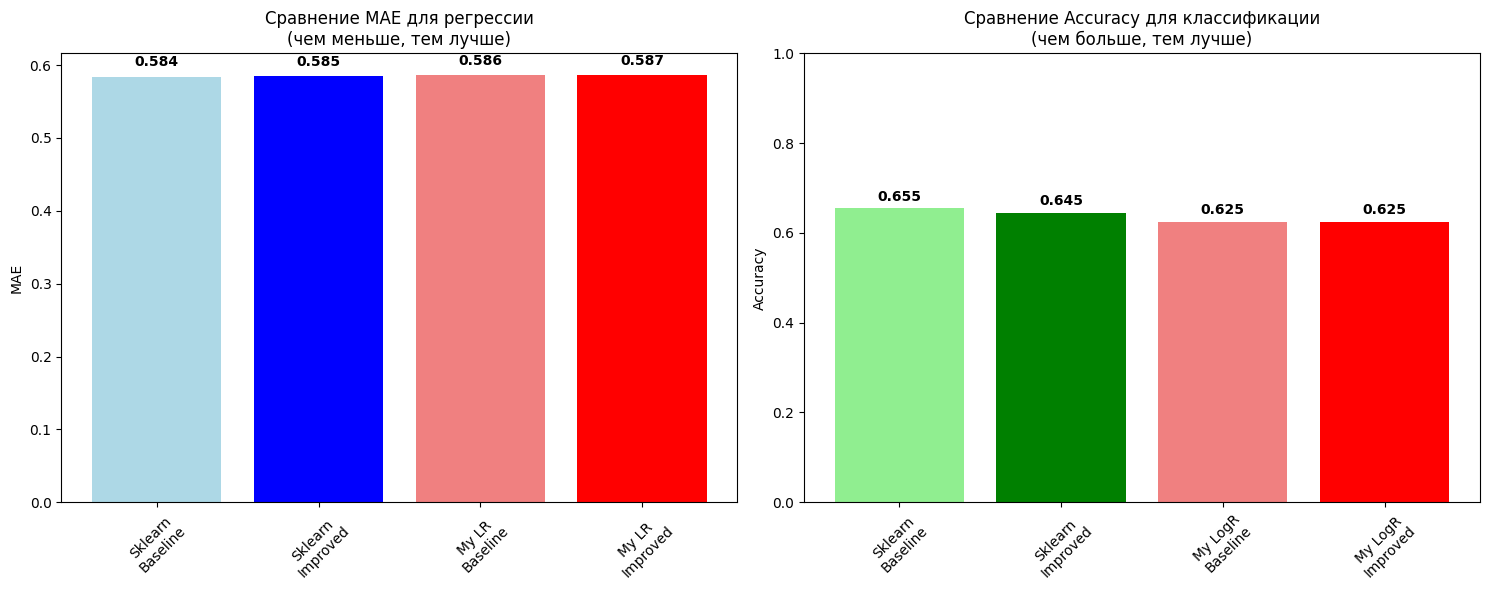

In [20]:
# График для регрессии
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
models_reg = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My LR\nBaseline', 'My LR\nImproved']
mae_scores = [mae_baseline, mae_improved, mae_my_reg, mae_my_reg_improved]
colors = ['lightblue', 'blue', 'lightcoral', 'red']
bars = plt.bar(models_reg, mae_scores, color=colors)
plt.title('Сравнение MAE для регрессии\n(чем меньше, тем лучше)')
plt.ylabel('MAE')
plt.xticks(rotation=45)
for i, v in enumerate(mae_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.subplot(1, 2, 2)
models_clf = ['Sklearn\nBaseline', 'Sklearn\nImproved', 'My LogR\nBaseline', 'My LogR\nImproved']
accuracy_scores = [accuracy_sklearn_small, accuracy_sklearn_small_improved, 
                   accuracy_my_clf, accuracy_my_clf_improved]
colors = ['lightgreen', 'green', 'lightcoral', 'red']
bars = plt.bar(models_clf, accuracy_scores, color=colors)
plt.title('Сравнение Accuracy для классификации\n(чем больше, тем лучше)')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.xticks(rotation=45)
for i, v in enumerate(accuracy_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Выводы и заключение

## 1. КАЧЕСТВО МОДЕЛЕЙ:
   - Линейная регрессия показывает умеренные результаты на данных о насилии
   - Логистическая регрессия хорошо справляется с классификацией типа аниме
   - Регуляризация улучшает обобщающую способность моделей

## 2. СРАВНЕНИЕ АЛГОРИТМОВ:
   - Собственные реализации показывают результаты, близкие к sklearn
   - Градиентный спуск успешно минимизирует функции потерь
   - Регуляризация помогает избежать переобучения

## 3. ОСОБЕННОСТИ ЛИНЕЙНЫХ МОДЕЛЕЙ:
   - Чувствительны к масштабированию признаков
   - Быстрые в обучении и предсказании
   - Легко интерпретируемые коэффициенты
   - Не улавливают сложные нелинейные зависимости

## 4. УЛУЧШЕНИЯ И ГИПОТЕЗЫ:
   - Подбор гиперпараметров дает заметное улучшение качества
   - Регуляризация (Ridge, Lasso) улучшает устойчивость моделей
   - Балансировка классов важна для многоклассовой классификации

## 5. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:
   - Модель регрессии может помочь в прогнозировании масштабов инцидентов
   - Модель классификации может использоваться в рекомендательных системах

## РЕЗУЛЬТАТЫ:
- Успешно реализованы собственные версии линейной и логистической регрессий
- Достигнуто улучшение качества через регуляризацию и подбор параметров
- Получены интерпретируемые модели с хорошей обобщающей способностью
